In [25]:
import requests
import pandas as pd
import time
from datetime import datetime

def fetch_us_data_monthly(start_yr=1985, end_yr=2025):
    base_url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    all_quakes = []
    
    for year in range(start_yr, end_yr + 1):
        for month in range(1, 13):
            # Define start and end of the month
            start_date = f"{year}-{month:02d}-01"
            # Handle end of month (simplified: just use the 1st of next month/year)
            if month == 12:
                end_date = f"{year+1}-01-01"
            else:
                end_date = f"{year}-{month+1:02d}-01"
                
            print(f"Fetching: {start_date} to {end_date}...", end="\r")
            
            params = {
                "format": "geojson",
                "starttime": start_date,
                "endtime": end_date,
                "minlatitude": 24.6,
                "maxlatitude": 50.0,
                "minlongitude": -125.0,
                "maxlongitude": -65.0,
                "minmagnitude": 1.5, 
                "eventtype": "earthquake",
                "orderby": "time-asc"
            }

            try:
                response = requests.get(base_url, params=params, timeout=30)
                
                if response.status_code == 204: 
                    continue
                
                # Check if response is actually JSON
                if "application/json" not in response.headers.get("Content-Type", ""):
                    print(f"\nNon-JSON response in {start_date}: {response.text[:100]}")
                    continue

                data = response.json()
                
                if 'features' not in data:
                    continue

                for feature in data['features']:
                    prop = feature['properties']
                    geom = feature['geometry']['coordinates']
                    dt = pd.to_datetime(prop['time'], unit='ms')
                    all_quakes.append({
                        "time": dt.strftime('%Y-%m-%dT%H:%M:%S.%f'),
                        "magnitude": prop['mag'],
                        "longitude": geom[0],
                        "latitude": geom[1],
                        "depth_km": geom[2]
                    })
                
                # API respect
                time.sleep(0.1) 
                
            except Exception as e:
                print(f"\nError fetching {start_date}: {e}")
                continue

    df = pd.DataFrame(all_quakes)
    return df

# Execute
df_final = fetch_us_data_monthly().dropna()

if not df_final.empty:
    print(f"\nProcess complete! Total events collected: {len(df_final)}")
    df_final.to_csv("data/USGS/us_earthquakes_1985_2025.csv", index=False)
    print("File saved: data/USGS/us_earthquakes_1985_2025.csv")

Fetching: 2025-12-01 to 2026-01-01...
Process complete! Total events collected: 689530
File saved: data/USGS/us_earthquakes_1985_2025.csv


In [31]:
df_final = pd.read_csv("data/USGS/us_earthquakes_1985_2025.csv")
df_final.head()

,time,magnitude,longitude,latitude,depth_km
0,1985-01-01T00:47:31.230000,1.57,-121.013167,36.437167,5.600
1,1985-01-01T00:53:22.800000,1.72,-116.796000,34.033000,11.954
2,1985-01-01T02:49:27.190000,1.56,-122.796000,38.830500,0.526
3,1985-01-01T03:03:42.380000,1.61,-122.794833,38.808333,0.490
4,1985-01-01T04:49:16.390000,1.53,-121.968167,37.770833,8.665


Loading the USA dataset...
Dataset ready: 689530 earthquakes loaded.


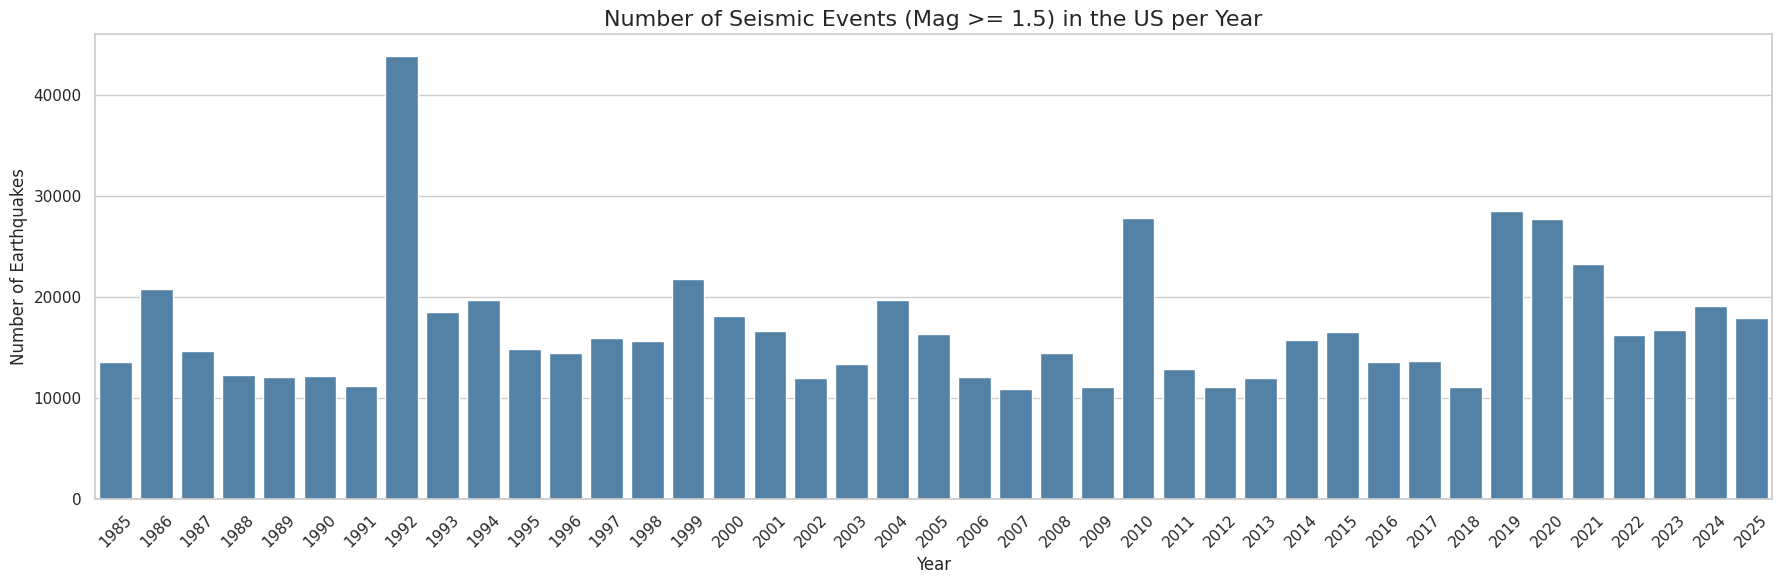

/tmp/ipykernel_1112499/3282467559.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')


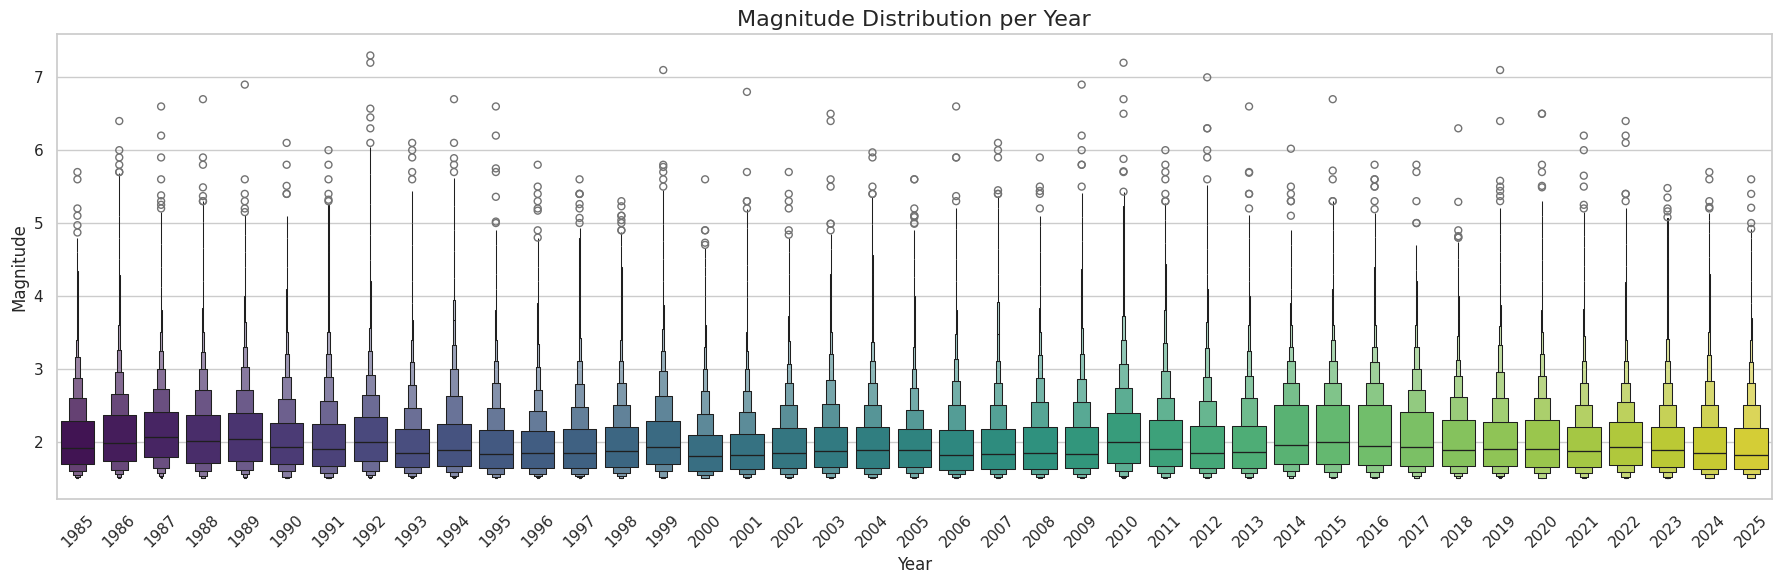

/tmp/ipykernel_1112499/3282467559.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth_km', palette='magma')


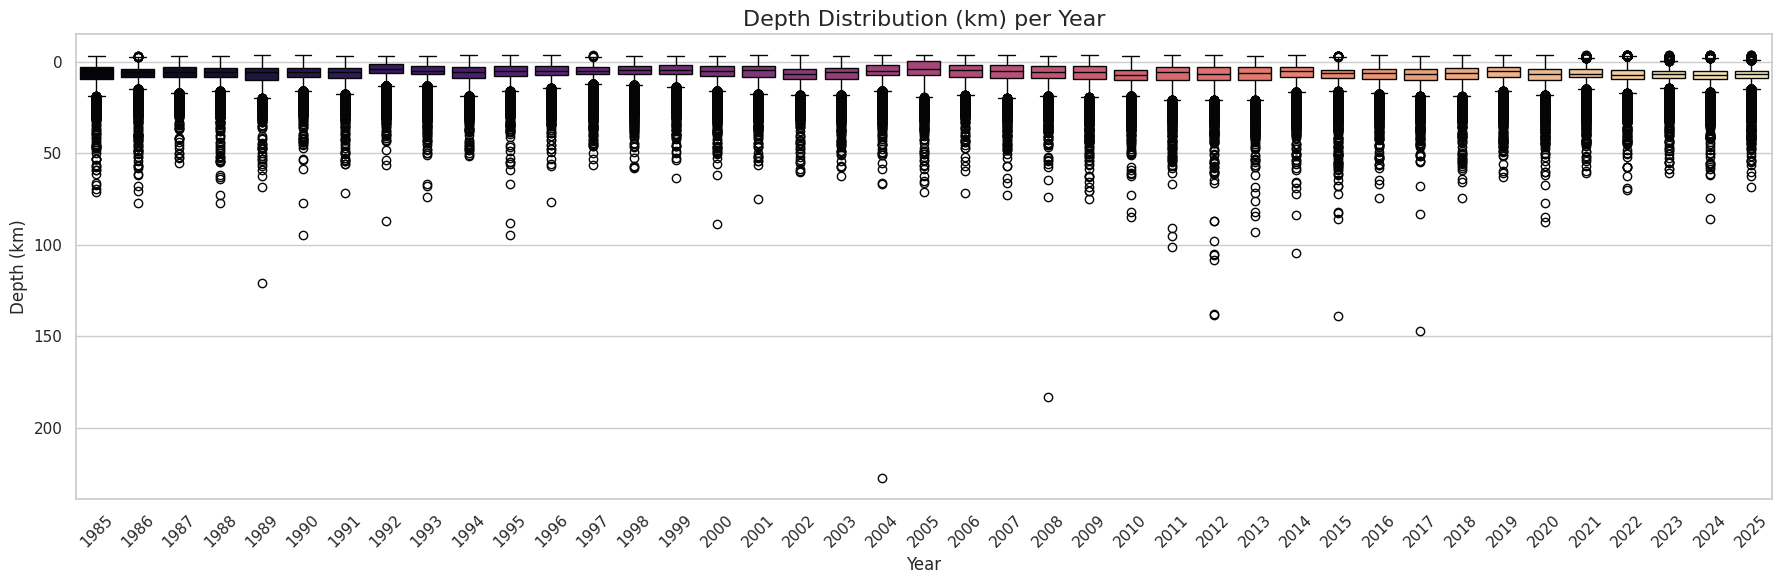

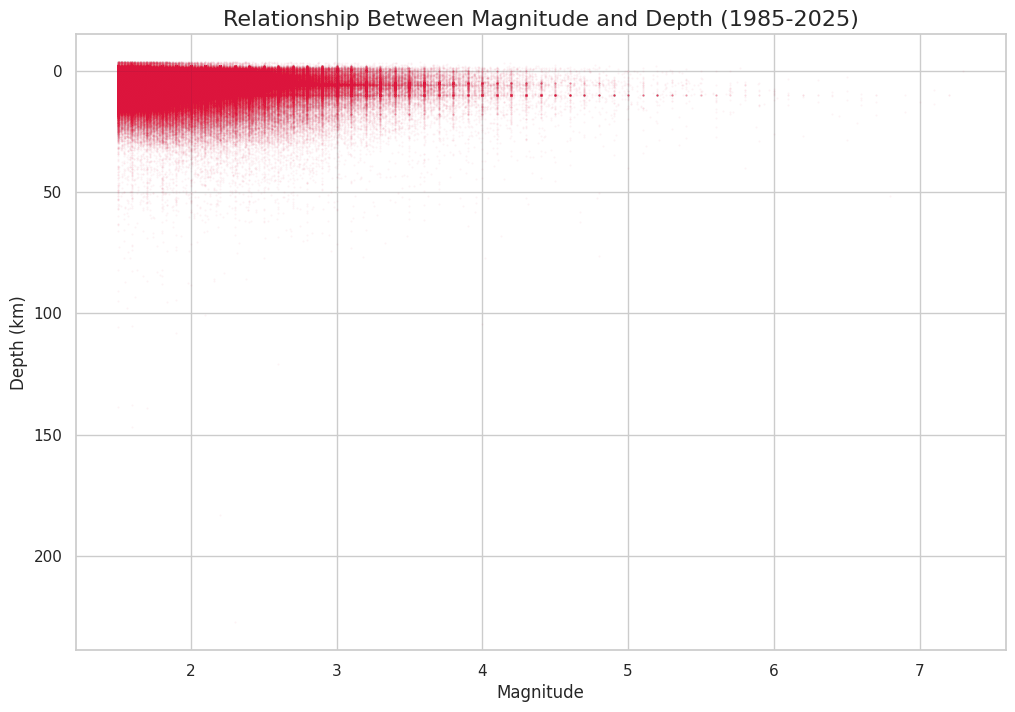

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline
print("Loading the USA dataset...")
df = pd.read_csv("data/USGS/us_earthquakes_1985_2025.csv")

df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year

print(f"Dataset ready: {len(df)} earthquakes loaded.")

# Earthquake Frequency Over Time
plt.figure(figsize=(18, 6))
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events (Mag >= 1.5) in the US per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

# Magnitude Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

# Depth Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='year', y='depth_km', palette='magma')
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

# Relationship Between Depth and Magnitude
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='magnitude', y='depth_km', alpha=0.05, s=2, color='crimson')
plt.gca().invert_yaxis()
plt.title('Relationship Between Magnitude and Depth (1985-2025)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

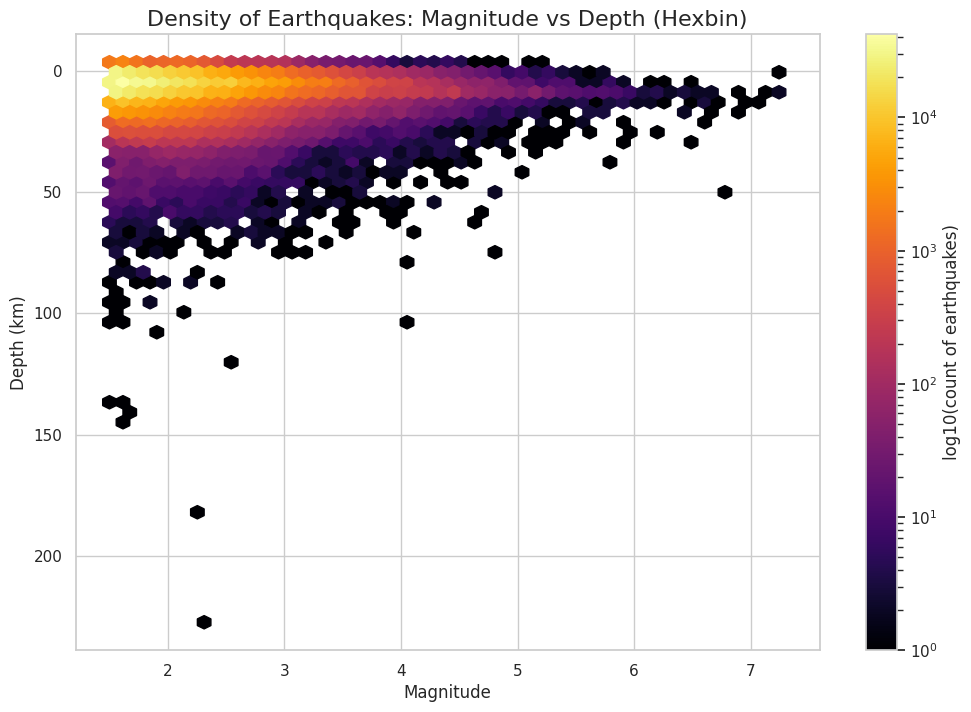

In [27]:
plt.figure(figsize=(12, 8))
hb = plt.hexbin(df['magnitude'], df['depth_km'], gridsize=50, cmap='inferno', mincnt=1, bins='log')

plt.colorbar(hb, label='log10(count of earthquakes)')
plt.gca().invert_yaxis()
plt.title('Density of Earthquakes: Magnitude vs Depth (Hexbin)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

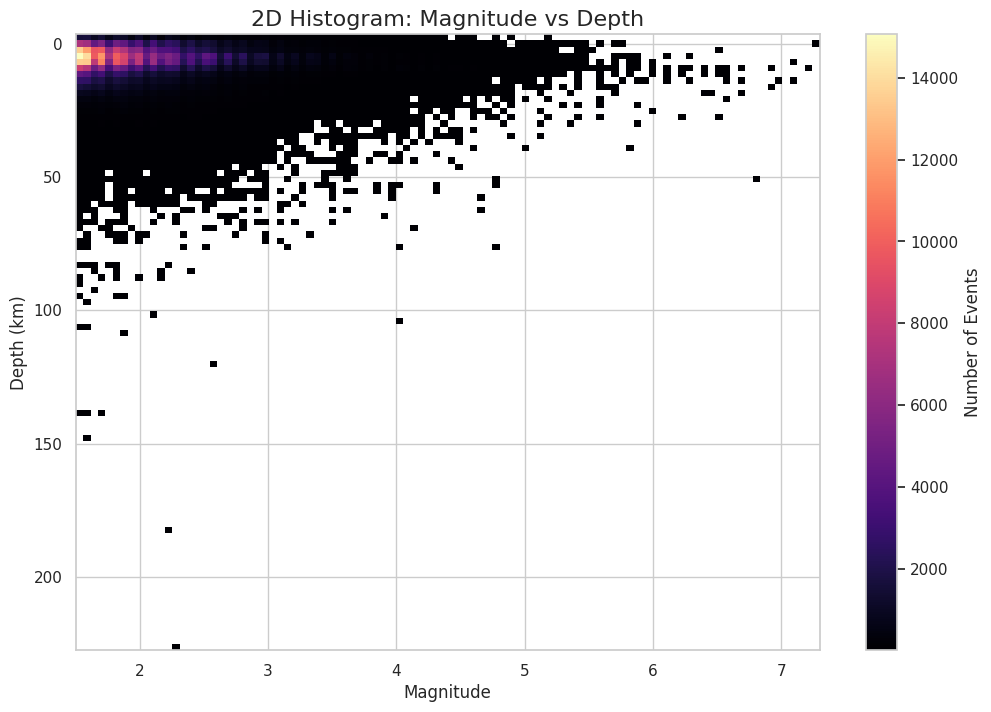

In [28]:
plot_df = df[['magnitude', 'depth_km']]
plt.figure(figsize=(12, 8))
plt.hist2d(plot_df['magnitude'], plot_df['depth_km'], bins=100, cmap='magma', cmin=1)
plt.colorbar(label='Number of Events')
plt.gca().invert_yaxis()
plt.title('2D Histogram: Magnitude vs Depth', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

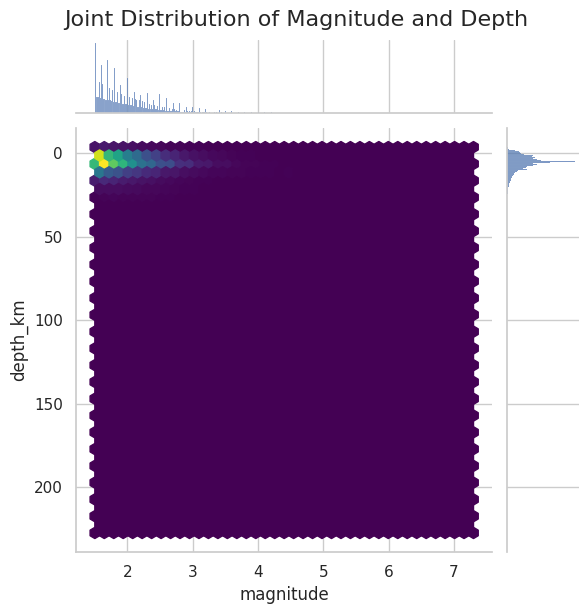

In [29]:
g = sns.jointplot(data=df, x='magnitude', y='depth_km', kind='hex', cmap='viridis', gridsize=40)
g.ax_joint.invert_yaxis()
g.fig.suptitle('Joint Distribution of Magnitude and Depth', y=1.02, fontsize=16)
plt.show()

/tmp/ipykernel_1112499/4198302734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)


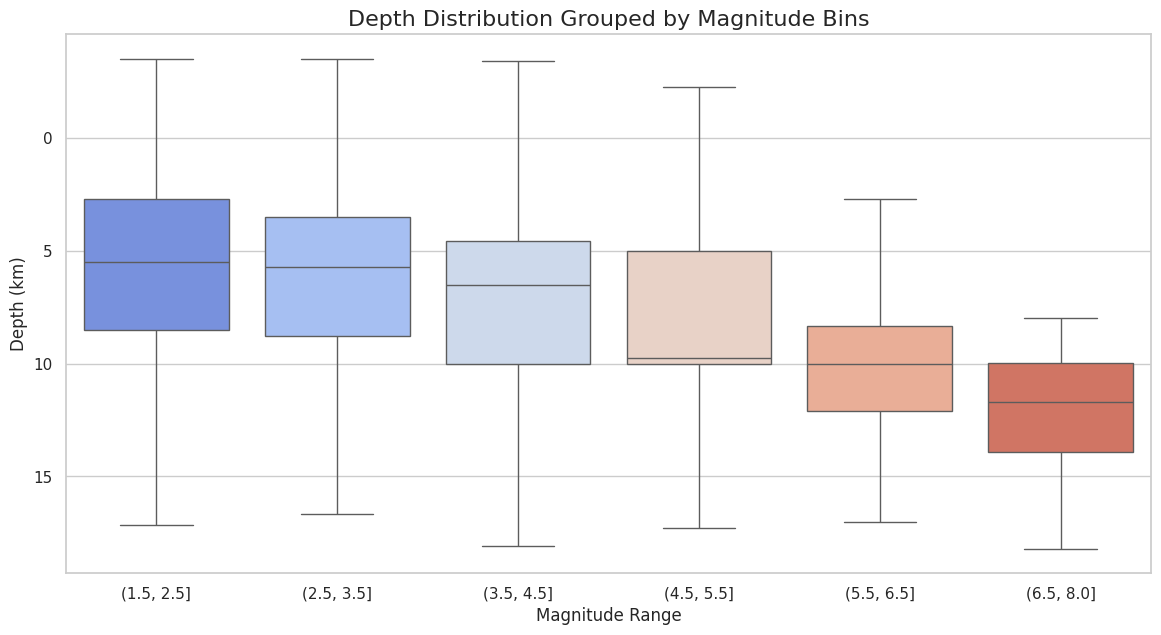

In [30]:
plt.figure(figsize=(14, 7))
# Create magnitude bins (e.g., 1.5-2.0, 2.0-2.5, etc.)
df['mag_bin'] = pd.cut(df['magnitude'], bins=[1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.0])

sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)
plt.gca().invert_yaxis()
plt.title('Depth Distribution Grouped by Magnitude Bins', fontsize=16)
plt.xlabel('Magnitude Range')
plt.ylabel('Depth (km)')
plt.show()